<a href="https://colab.research.google.com/github/scelliot-cpu/Elliott_DSPN_26/blob/master/ExerciseSubmissions/11_the-beauty-of-knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 11: The beauty of kNN

In this exercise, you'll gain practice working with kNN. We'll use the [diamonds](https://ggplot2.tidyverse.org/reference/diamonds.html) dataset, which comes as part of `ggplot2`. This dataset provides information on the quality and price of 50,000 diamonds.


-----
## 1. Data, Plotting, and Train/Test Sets (2 points)
* Load the the `class` and `tidyverse` packages.
* Assign the `diamonds` data set to a simpler name. Then, create a new variable `price_bin` that splits the `price` variable into a binary variable, where 1 indicates that the diamond costs greater than the mean price, and 0 indicates that the diamond costs less than the mean price. Set `price_bin` to be a factor. (*Hint: use the if_else() function*)
* Select just the `carat`, `depth`, `table`, `x`, `y`, and your new `price_bin` variables
* Print the first few lines of the data set
* Print the dimensions of the data set


In [1]:
library(tidyverse)
library(class)

df <- diamonds
df <- df %>% mutate(price_bin = if_else(price > mean(price), 1, 0))
df <- df %>% select(carat, depth, table, x, y, price_bin)
head(df)
dim(df)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


carat,depth,table,x,y,price_bin
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.23,61.5,55,3.95,3.98,0
0.21,59.8,61,3.89,3.84,0
0.23,56.9,65,4.05,4.07,0
0.29,62.4,58,4.20,4.23,0
0.31,63.3,58,4.34,4.35,0
0.24,62.8,57,3.94,3.96,0


[1] 53940     6

### Plot
Create a scatterplot of the link between `carat` and `depth`, and use the `color` aesthetics mapping to differentiate between diamonds that cost above versus below the mean price.

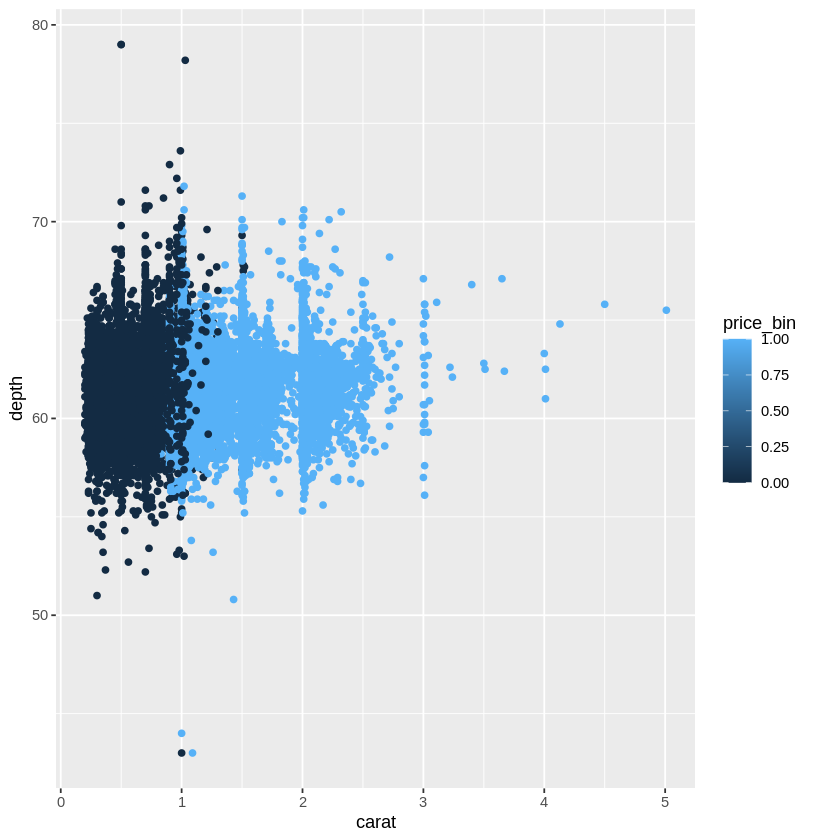

In [2]:
ggplot(df, aes(x = carat, y = depth, color = price_bin)) + geom_point()

Based on the above scatterplot, how do you think kNN will perform using only these two variables to predict diabetes diagnosis? Which variable, carat or depth, gives us the most information about which price class the diamond will belong to?
> **The kNN will perform somewhat well using only these two variables. There is some overlap between the two groups, which many cause a nearest neighbor to belong to a different group. The carat variable definitely gives more information about the price class the diamond will belong two, as the diamonds with a carat 1 or higher tend to belong to the higher price bin and those below 1 tend to belong to the lower price bin. There is pretty much no seperation with the depth variable.


### Test vs Train

Before we run KNN on these data, we need to set aside a portion of the observations as our test set. Below, randomly divide the data such that 30% are allotted to the `test` set and the rest are allotted to the `train` set. Print the first few lines of each set, and print the dimensions of each set to double check your division of the data.

In [3]:
set.seed(2023)

test.inds <- sample(1:nrow(df), size = floor(0.3 * nrow(df)))
df$is.test <- 1:nrow(df) %in% test.inds

train <- df[!df$is.test,]
test <- df[df$is.test,]

head(train)
head(test)
dim(train)
dim(test)

carat,depth,table,x,y,price_bin,is.test
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
0.23,61.5,55,3.95,3.98,0,FALSE
0.23,56.9,65,4.05,4.07,0,FALSE
0.29,62.4,58,4.20,4.23,0,FALSE
0.31,63.3,58,4.34,4.35,0,FALSE
0.24,62.8,57,3.94,3.96,0,FALSE
0.24,62.3,57,3.95,3.98,0,FALSE


carat,depth,table,x,y,price_bin,is.test
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
0.21,59.8,61,3.89,3.84,0,TRUE
0.30,64.0,55,4.25,4.28,0,TRUE
0.30,62.0,54,4.31,4.34,0,TRUE
0.30,63.4,54,4.23,4.29,0,TRUE
0.30,62.7,59,4.21,4.27,0,TRUE
0.23,63.8,55,3.85,3.92,0,TRUE


[1] 37758     7

[1] 16182     7

-----
## 2. KNN (3 points)
Now, use the `knn()` function from the `class` library to predict `price_bin` from the `carat` and `depth`. Set `k = 3`.

*Hint: Review the format required for the arguments of knn()*

In [15]:
set.seed(2023)
train.preds <- cbind(df$carat[-test.inds], df$depth[-test.inds])
train.price <- df$price_bin[-test.inds]
test.preds <- cbind(df$carat[test.inds], df$depth[test.inds])
train.price.knn <- knn(train.preds, test.preds, train.price, k = 3)
train.price.knn[1:10]

[1] 1 1 1 0 0 1 1 0 0 0
Levels: 0 1

Now, output a confusion matrix and calculate the test error to evaluate model performance.

In [17]:
confusion_df <- data.frame(predicted = train.price.knn, actual = df$price_bin[test.inds])

table(confusion_df)

print(paste("Accuracy:",mean(confusion_df$predicted == confusion_df$actual)))

         actual
predicted    0    1
        0 9707  316
        1  539 5620

[1] "Accuracy: 0.947163515016685"


How did your model perform?
> * The model performed relatively well, with an accuracy of 0.947 (test error of 0.053). There were 539 false positives and 316 false negatives.



Let's try to improve our model by adding all of the other variables in our data set as predictors. Rerun your `knn()` below, keeping `k = 3`. Again, output a confusion matrix and error rate for your updated model fit.

In [18]:
train.preds <- df[-test.inds, c("carat","depth","table","x","y")]
train.price <- df$price_bin[-test.inds]
test.preds <- df[test.inds, c("carat","depth","table","x","y")]
knn(train.preds, test.preds, train.price, k = 3)
train.price.knn <- knn(train.preds, test.preds, train.price)

confusion_df <- data.frame(predicted = train.price.knn, actual = df$price_bin[test.inds])
table(confusion_df)
print(paste("Accuracy:",mean(confusion_df$predicted == confusion_df$actual)))

[1] 1 1 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 1 0 0 1 0 1 0 1 0 1
   [37] 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 1 0 1 1 1 1 0 0 1 0 0 0 0
   [73] 0 0 0 1 1 1 0 1 1 0 0 1 0 0 1 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 1
  [109] 1 1 0 0 0 1 1 0 1 1 1 0 1 1 0 0 0 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1
  [145] 0 0 0 0 0 0 0 0 1 0 1 1 0 1 1 1 1 1 0 1 0 0 0 1 0 1 0 0 1 0 0 0 1 1 0 0
  [181] 0 0 0 0 0 0 0 0 1 0 1 1 0 1 0 0 0 1 1 1 1 0 0 0 1 1 0 0 1 0 0 0 0 1 0 0
  [217] 1 1 0 0 0 0 0 0 0 0 1 0 1 1 0 1 0 1 1 1 1 0 1 1 0 1 0 1 0 0 1 0 1 1 1 0
  [253] 1 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 1 0 1 0 1 0 1 0 1 0 0 1 1 1 1 0 1 0
  [289] 0 1 0 0 1 1 0 1 1 0 1 0 1 0 1 0 1 0 1 1 0 1 0 0 0 0 1 0 1 1 0 0 1 0 0 1
  [325] 0 0 0 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0
  [361] 1 0 0 1 1 0 1 0 0 0 1 0 1 1 0 1 1 1 1 0 0 0 0 1 1 0 1 0 0 0 1 0 1 1 0 0
  [397] 0 1 0 0 1 1 1 1 0 0 1 1 0 1 0 1 0 1 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0 1 0 0
  [433] 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 1 1 0 1 0 0
  [469] 1 0 0 0 0 1 1 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 0 1 0 1 1 0 1 1 1 1 1 0 0 0
  [505] 0 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 1 0 0 1 1 1 0 1 1 0 1 0 0 0 0
  [541] 0 1 0 1 1 1 0 0 0 0 0 1 1 1 1 1 0 0 1 0 0 0 0 1 1 1 0 1 0 0 0 0 0 1 0 0
  [577] 1 1 0 1 1 1 0 1 0 1 1 0 0 1 0 0 0 1 1 0 0 0 0 0 0 1 0 1 1 0 0 1 0 0 1 0
  [613] 1 0 1 0 0 0 0 1 1 0 0 1 1 1 0 1 0 0 0 0 1 0 0 1 1 1 1 0 1 0 0 0 1 0 0 0
  [649] 0 0 0 0 1 1 1 1 0 0 1 1 0 1 0 0 0 0 1 0 0 1 0 1 0 1 1 1 0 0 0 0 0 0 0 1
  [685] 0 0 1 1 0 0 0 0 1 1 0 0 0 0 0 0 1 0 1 1 0 1 1 0 0 0 0 0 0 0 1 1 1 0 1 0
  [721] 0 1 0 1 0 1 0 0 1 1 1 1 0 0 0 1 1 1 0 0 0 0 1 0 1 0 1 1 1 0 0 0 0 0 0 0
  [757] 0 1 0 0 0 0 1 0 0 1 1 0 0 1 0 0 0 1 1 0 0 0 1 0 0 1 0 1 0 0 0 1 0 1 0 1
  [793] 0 0 1 1 0 1 0 0 1 1 0 0 1 1 0 0 0 0 0 0 0 1 0 1 0 1 0 0 1 0 0 0 1 0 1 0
  [829] 0 0 0 1 0 0 1 0 0 0 1 1 1 1 1 0 0 1 0 1 1 0 0 0 1 0 0 1 0 1 1 0 0 1 0 0
  [865] 1 1 1 1 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1 1 0 1 1
  [901] 1 0 1 1 1 1 0 1 1 0 0 1 0 1 0 1 0 0 0 0 0 1 0 1 1 1 0 0 1 1 0 1 0 0 1 1
  [937] 1 0 1 1 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 1 1 0 0 1 1 0 0 0 0 0 0
  [973] 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 0 0 1
 [1009] 0 0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 0 1 0 0 1 0 1 0 1 0 0 1 0 0 0 0 0 0 0 1
 [1045] 0 1 0 0 1 0 0 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1 1 0 0 0 0 1 0 0 0 0 1 1 0
 [1081] 0 0 0 1 0 1 1 0 0 1 1 0 0 1 0 0 0 1 0 0 1 0 0 1 1 1 1 0 0 1 0 1 0 0 0 0
 [1117] 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 1 1 0 1 1 1 0 0 0 1 1
 [1153] 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 1 0
 [1189] 0 0 1 0 0 0 0 0 1 1 0 1 1 1 0 1 1 0 0 1 1 0 0 0 1 1 1 0 0 1 0 1 1 1 1 0
 [1225] 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 1 1 0 0 0 1 0 0 1 1 0 0 0 1 1 0 0 1 0 0
 [1261] 0 1 1 0 1 0 0 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1
 [1297] 0 0 1 1 1 0 0 1 0 0 0 0 0 0 0 1 0 1 0 1 1 0 1 0 1 0 0 0 1 0 0 0 1 0 1 1
 [1333] 1 1 0 0 0 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 0 0 0 1 1 1 0 1 0 0 0 0 0 1 0 1
 [1369] 1 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0
 [1405] 1 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 1 1 0 1 0 0 0 0 0 1
 [1441] 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 1 0 0 0 1 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0
 [1477] 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 1 0 0 1 0 1 1 0 1 0 0 0 1 1 0 0 0 0 0
 [1513] 0 1 0 0 1 0 1 1 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 1 1 0 1 0 0 1 0 0 1
 [1549] 1 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0 1 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 [1585] 0 1 1 0 0 1 0 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 1 1 1 0 0 0 1 0 0
 [1621] 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 1 0 1 1 1 0 0 1 1 1 0 1 0 0 0 1 0 1
 [1657] 0 1 1 1 1 0 0 1 1 1 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1 1 0 1 1 1 0 0 0 1 0 0
 [1693] 0 0 0 1 1 0 0 0 0 1 1 1 1 1 0 1 0 0 0 0 1 1 1 0 1 1 1 1 1 0 0 0 0 1 0 0
 [1729] 0 0 0 0 0 1 1 0 0 0 1 0 1 1 1 1 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 1 0 0 0
 [1765] 1 0 0 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 0 0 1 1 0 1 0 0 1 0 0 0 1 0 1 0 1 1
 [18

         actual
predicted    0    1
        0 9709  516
        1  537 5420

[1] "Accuracy: 0.934927697441602"


Did your model predictions improve?
> * No the model predictions did not improve, now with an accuracy of 0.935, there were a lot more false negatives.
>
> * The additional variables may have introduced some noise and carat was already a good predictor.


-----
## 3. For loop (3 points)

So adding additional predictors didn't shift our error much. Let's see if adjusting `k` has a larger impact on model accuracy.

Using your initial model above with just `carat` and `depth`, run a `for loop` that runs the same model 30 times, for `k = 1:30`.

Output a data frame that has `k` and the overall `error` as columns.

The structure of the output data frame and `for loop` are provided for you below. Note that your loop will take a minute or two to run because there are so many observations in the dataset. It may be helpful while you are writing and testing your loop to run it on a subset of the data with only a handful of rows.

In [7]:
# this is provided
# setting up empty table to store for loop output
output  <- data.frame(k = seq(1:30),
                     error = rep(NA, 30))
head(output)

,k,error
,<int>,<lgl>
1,1,NA
2,2,NA
3,3,NA
4,4,NA
5,5,NA
6,6,NA


In [22]:
train.preds <- cbind(df$carat[-test.inds], df$depth[-test.inds])
train.price <- df$price_bin[-test.inds]
test.preds <- cbind(df$carat[test.inds], df$depth[test.inds])

for (k in seq(1:30)) {
    knn_fits  <- knn(train.preds, test.preds, train.price, k = k)

    #overall error
    conf_df  <- data.frame(predicted = knn_fits, actual = df$price_bin[test.inds])
    output$error[k]  <- mean(conf_df$predicted != conf_df$actual)

}
head(output)

,k,error
,<int>,<dbl>
1,1,0.05333086
2,2,0.05363985
3,3,0.05357805
4,4,0.05265109
5,5,0.05302188
6,6,0.05265109


Create a line plot of your `output` object using `ggplot`. Add a (non-linear) `geom_smooth` layer.

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


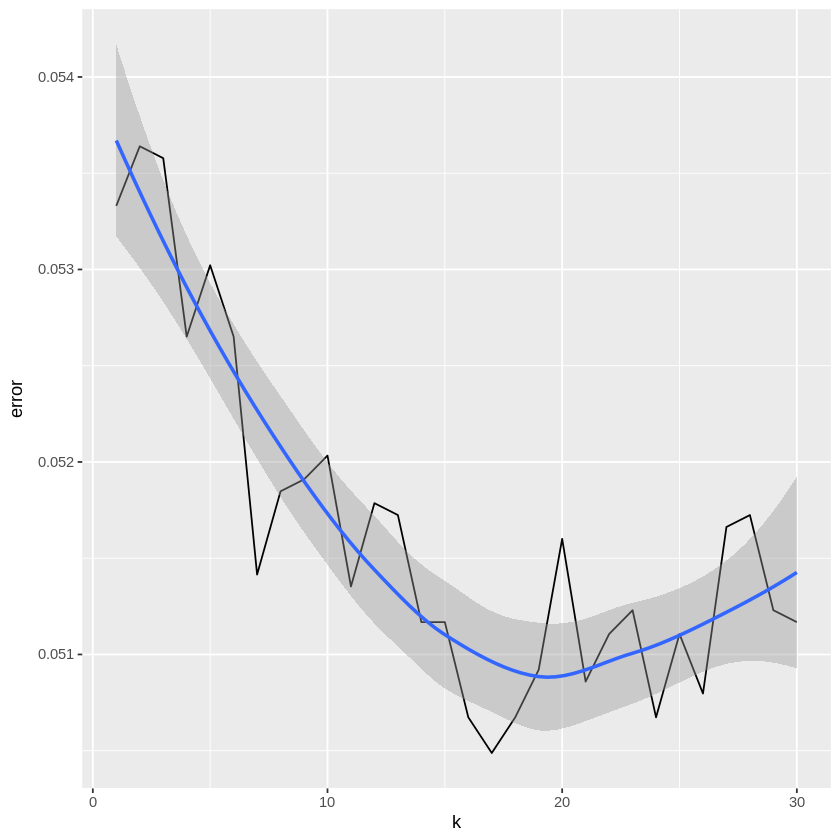

In [23]:
ggplot(output, aes(x = k, y = error)) + geom_line() + geom_smooth()

Interpret your plot. What would you select as the best value of `k`? How much does this improve your test error?
> * I would selected 17 as the best value of k. This improves the test error by around 0.2 percent.


-----
## 4. Standardizing predictors (2 points)

Because knn is based on distances between points, it is very sensitive to the scale of your variables. Looking at our predictor variables, we can see that `carat` and `depth` are orders of magnitude different in terms of scales. Maybe we can improve our fit even more by addressing this!

Below, use the `scale()` function to standardize your predictors. (Note that you don't need to standardize `price_bin`.)

Then, run your model a final time with your standardized predictors (just `carat` and `depth` still). Set `k` to the optimal value you determined in your plot above. Output the confusion matrix and error rate again.

In [25]:
set.seed(2023)
scaled.preds <- scale(df[c("carat", "depth")])
train.preds <- scaled.preds[-test.inds,]
train.price <- df$price_bin[-test.inds]
test.preds <- scaled.preds[test.inds, ]
test.price.knn <- knn(train.preds, test.preds, train.price, k = 17)

confusion_df  <- data.frame(predicted = test.price.knn, actual = df$price_bin[test.inds])
table(confusion_df)
print(paste("Accuracy:",mean(confusion_df$predicted == confusion_df$actual)))

         actual
predicted    0    1
        0 9713  284
        1  533 5652

[1] "Accuracy: 0.949511803238166"


What impact did rescaling the data have on your error rate?
> * The rescaling slightly improved the error rate.


**DUE:** 11:59pm March 17, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*
>
>


**GenAI Utilization** Did you utilize any generative AI tools on this assignment? If so, please list the item and the paste respective prompt you used.

ChatGPT: "how to change this line of code "train.preds <- cbind(df$carat[-test.inds], df$depth[-test.inds])" to account for more variables?" (didn't see in tutorial)